<h1>Mean Reversion<h1>

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

In [2]:
symbol = 'SLV'
start_date = '2015-01-01' 
end_date = '2022-12-31' 
data = yf.download(symbol, start=start_date, end=end_date)

[*********************100%***********************]  1 of 1 completed


In [3]:
data['SMA_21'] = data['Close'].rolling(window=21).mean()

In [4]:
data['ratio'] = data['Close']/data['SMA_21']

In [5]:
percentile = [15, 20, 50, 80, 85]
ratio = data['ratio'].dropna()
per_value = np.percentile(ratio, percentile)

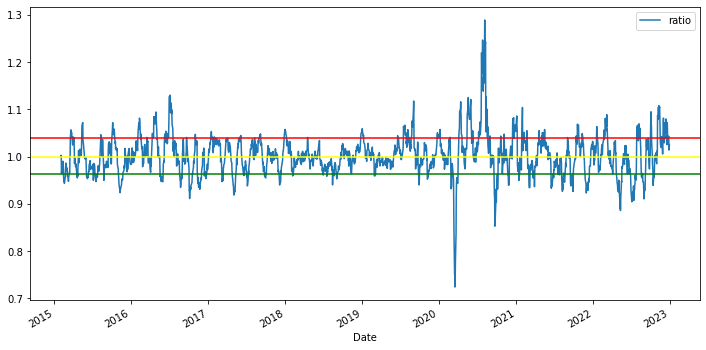

In [6]:
plt.figure(figsize=(12, 6)) 
data['ratio'].dropna().plot(legend = True)
plt.axhline(per_value[0], c='green', label = '15%')
plt.axhline(per_value[2], c='yellow', label = '50%')
plt.axhline(per_value[-1], c='red', label = '85%')

In [7]:
sell_thre = per_value[-1]
buy_thre = per_value[0]
data['Signal'] = np.where(data['ratio'] > sell_thre, -1, 0)
data['Signal'] = np.where(data['ratio'] < buy_thre, 1, data['Signal'])

In [8]:
data['Signal'].describe()

count    2014.00000
mean        0.00000
std         0.54504
min        -1.00000
25%         0.00000
50%         0.00000
75%         0.00000
max         1.00000
Name: Signal, dtype: float64

In [9]:
data['Buy'] = np.where(data['Signal'] == 1, data['Close'], np.nan)
data['Sell'] = np.where(data['Signal'] == -1, data['Close'], np.nan)

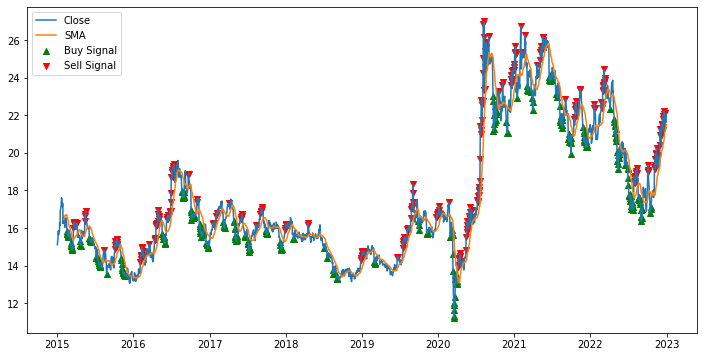

In [10]:
plt.figure(figsize=(12, 6)) 
plt.plot(data['Close'], label = 'Close')
plt.plot(data['SMA_21'], label = 'SMA')
plt.scatter(data.index, data['Buy'], color = 'green', label = 'Buy Signal', marker= '^')
plt.scatter(data.index, data['Sell'], color = 'red', label = 'Sell Signal', marker= 'v')
plt.legend()
plt.show()

In [11]:
data['Daily_Return'] = data['Close'].pct_change() 
data['Log_Return'] = np.log(1 + data['Daily_Return'])
data['Strategy_Return'] = data['Log_Return'] * data['Signal'].shift(1) 
data['Cumulative_Return'] = np.exp(data['Strategy_Return'].dropna()).cumprod()

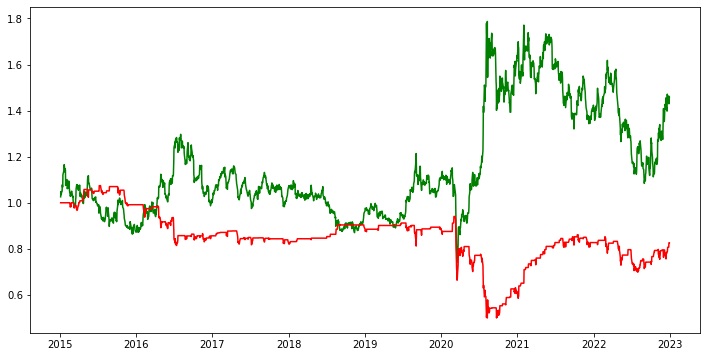

In [12]:
plt.figure(figsize=(12, 6)) 
plt.plot(np.exp(data['Log_Return'].dropna()).cumprod(), c = 'green', label='Buy and Hold') 
plt.plot(data['Cumulative_Return'],c = 'red', label='Mean Reversion') 